<a href="https://colab.research.google.com/github/sparshi15/Advanced-AI-Based-Air-Quality-Prediction-Early-Warning-System/blob/main/clg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn tensorflow

In [ ]:
import kagglehub

path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

print("Dataset Path:", path)


100%|██████████| 72.9M/72.9M [00:02<00:00, 32.4MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/rohanrao/air-quality-data-in-india/versions/12


In [ ]:
import os

print("Files inside dataset folder:")
print(os.listdir(path))

Files inside dataset folder:
['stations.csv', 'city_hour.csv', 'station_hour.csv', 'city_day.csv', 'station_day.csv']


In [ ]:
import pandas as pd

file_path = os.path.join(path, "city_hour.csv")
df = pd.read_csv(file_path)

df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [ ]:
df = df[df['City'] == 'Delhi']

print("Delhi Dataset Shape:", df.shape)
df.head()

Delhi Dataset Shape: (48192, 16)


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
245172,Delhi,2015-01-01 01:00:00,454.58,935.18,81.52,41.78,187.66,27.54,9.29,3.41,54.94,25.24,58.57,13.80,NaN,NaN
245173,Delhi,2015-01-01 02:00:00,440.44,NaN,70.80,43.46,176.83,27.72,13.28,3.88,50.53,23.10,49.37,15.63,NaN,NaN
245174,Delhi,2015-01-01 03:00:00,409.09,NaN,132.46,41.19,141.02,28.94,29.67,2.83,19.33,19.04,38.94,17.18,NaN,NaN
245175,Delhi,2015-01-01 04:00:00,436.12,NaN,84.78,39.55,102.84,29.30,21.76,4.33,20.08,13.99,27.53,16.82,NaN,NaN
245176,Delhi,2015-01-01 05:00:00,415.88,976.99,60.24,37.41,80.12,30.84,26.19,6.17,16.00,11.14,21.99,14.29,NaN,NaN


In [ ]:
# Convert Datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Sort chronologically
df = df.sort_values('Datetime')

# Remove missing values
df = df.dropna()

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (29059, 16)


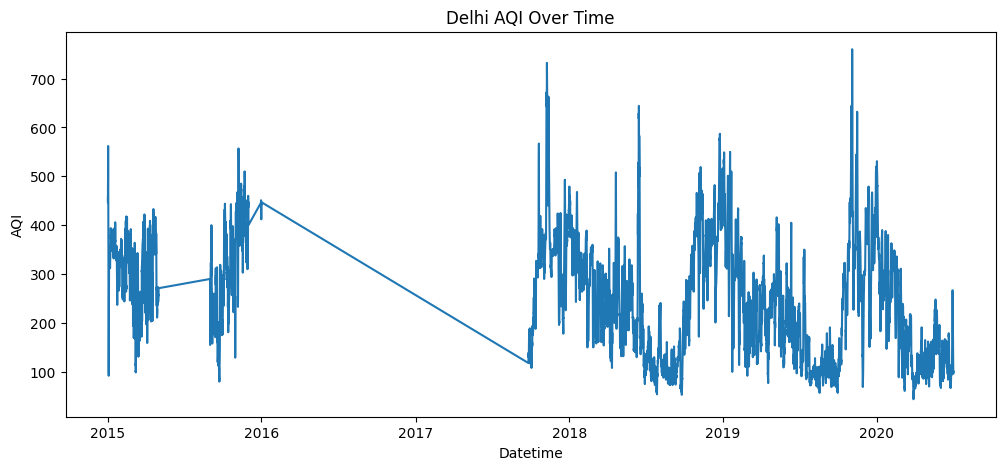

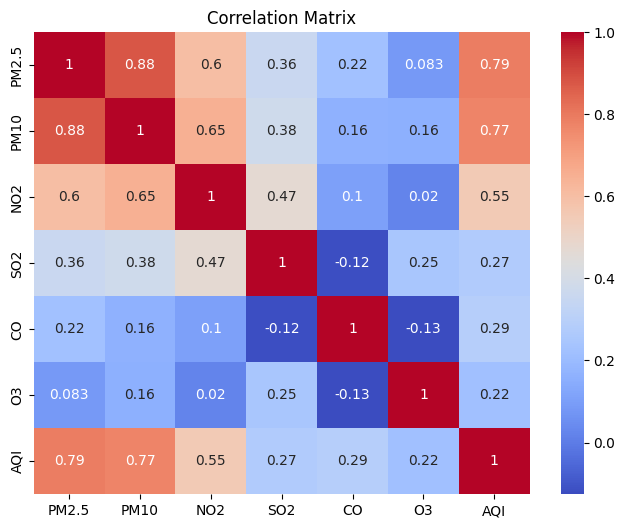

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# AQI over time
plt.figure(figsize=(12,5))
plt.plot(df['Datetime'], df['AQI'])
plt.title("Delhi AQI Over Time")
plt.xlabel("Datetime")
plt.ylabel("AQI")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['PM2.5','PM10','NO2','SO2','CO','O3','AQI']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
features = ['PM2.5','PM10','NO2','SO2','CO','O3','AQI']
data = df[features].values
print("Data Shape:", data)


Data Shape: [[211.51 340.66  37.08 ...  15.24  34.35 456.  ]
 [191.12 257.4   38.4  ...  13.11  34.38 450.  ]
 [218.44 351.01  44.73 ...  18.35  38.42 446.  ]
 ...
 [ 49.04 129.39  20.95 ...   1.    38.95 101.  ]
 [ 50.51 128.86  20.4  ...   0.94  34.53 102.  ]
 [ 54.01 128.66  21.05 ...   0.97  29.73 101.  ]]


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
def create_sequences(data, window=24):  # 24 hours window
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window][-1])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, 24)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (29035, 24, 7)
y shape: (29035,)


In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(24,7)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - loss: 0.0037 - val_loss: 4.9216e-04
Epoch 2/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 9.3587e-04 - val_loss: 1.6545e-04
Epoch 3/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 6.3867e-04 - val_loss: 1.0057e-04
Epoch 4/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 5.4266e-04 - val_loss: 1.5664e-04
Epoch 5/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 4.4965e-04 - val_loss: 1.0707e-04
Epoch 6/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - loss: 3.7153e-04 - val_loss: 7.8360e-05
Epoch 7/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 3.1710e-04 - val_loss: 3.7885e-05
Epoch 8/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - loss: 3.0004e-04 - val_loss: 5.1908e-05
Epoch 9/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - loss: 3.0656e-04 - val_loss: 3.4331e-05
Epoch 10/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - loss: 3.2192e-04 - val_loss: 2.8643e-05


In [ ]:
from sklearn.metrics import mean_squared_error

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Mean Squared Error: 2.8643162805691885e-05


In [ ]:
last_24 = data_scaled[-24:]
last_24 = np.reshape(last_24, (1,24,7))

next_pred = model.predict(last_24)

print("Next Hour AQI (Scaled):", next_pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Next Hour AQI (Scaled): 0.0807893


In [ ]:
model.save("delhi_lstm_model.h5")

In [ ]:
model.save('my_model.keras')